In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from google.colab import files
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

In [2]:
df1 = pd.read_csv('fb_data_new(4).csv')
df1.head()

,url,text,likes,comments1,comments,shares_n,shares_t,shares,time,sf,...,start date,d date,page active,person,plant,cluster1,cluster2,cluster3,pfr,sfr
0,https://www.facebook.com/IKEAIndia/posts/pfbid...,"A weekend of connection, conversations, belong...",26,0,0,0,95,47.0,18,0,...,11-05-2009,16-03-2026,6153,0,1,NaN,1,1,0,0
1,https://www.facebook.com/Pepperfry/posts/pfbid...,"This Women’s Day, give your home a smart upgra...",27,41,41,19,0,0.0,18,0,...,02-10-2001,16-03-2026,8931,0,1,NaN,1,0,0,0
2,https://www.facebook.com/Pepperfry/posts/pfbid...,"If not on a Tuesday, then when?🪧🏴🕯️\n\n#pepper...",17,41,41,37,0,0.0,26,0,...,02-10-2001,16-03-2026,8931,0,0,NaN,1,1,0,0
3,https://www.facebook.com/Pepperfry/posts/pfbid...,From the hands that craft it with care to the ...,17,41,41,1,89,44.0,45,0,...,02-10-2001,16-03-2026,8931,0,1,NaN,1,0,0,0
4,https://www.facebook.com/wayfair/posts/pfbid02...,Our 72-Hour Clearout is BACK ⏰ ❄️ 📆 Save up to...,76,33,33,3,0,0.0,57,0,...,25-08-2011,16-03-2026,5317,0,1,NaN,0,0,0,0


In [3]:
display(df1['revenue'])

,revenue
0,1.450000
1,2.849599
2,2.386887
3,1.450000
4,1.745256
...,...
2186,1.450000
2187,1.450000
2188,7.722011
2189,1.499301


In [4]:
s1=df1.describe()
display(s1)

,likes,comments1,comments,shares_n,shares_t,shares,time,sf,pf,saturation,...,post_interval,revenue,page active,person,plant,cluster1,cluster2,cluster3,pfr,sfr
count,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,...,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,0.0,2191.000000,2191.000000,2191.000000,2191.000000
mean,61.014149,35.855774,35.996349,13.614788,26.103149,20.901552,383.238247,3.863989,1.712460,56.933364,...,3.584665,4.136438,5749.580557,0.482428,0.504336,NaN,0.502510,0.485623,1.675491,3.829302
std,329.668500,63.076023,63.154923,24.427760,36.379611,26.257562,373.904780,3.093480,1.692429,44.167584,...,4.936031,2.271682,1444.268133,0.499805,0.500095,NaN,0.500108,0.499907,1.614188,3.057154
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,-7.000000,1.450000,2880.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,10.000000,4.000000,4.000000,1.000000,0.000000,0.000000,145.000000,1.000000,1.000000,25.000000,...,2.000000,1.931496,5317.000000,0.000000,0.000000,NaN,0.000000,0.000000,1.000000,1.000000
50%,23.000000,29.000000,29.000000,2.000000,10.000000,9.000000,302.000000,3.000000,1.000000,47.000000,...,2.000000,3.867962,5534.000000,0.000000,1.000000,NaN,1.000000,0.000000,1.000000,3.000000
75%,47.500000,45.000000,45.000000,15.000000,43.000000,36.000000,477.000000,6.000000,3.000000,78.500000,...,4.000000,5.704363,6276.000000,1.000000,1.000000,NaN,1.000000,1.000000,2.000000,6.000000
max,10000.000000,573.000000,573.000000,388.000000,282.000000,149.000000,2391.000000,18.000000,19.000000,255.000000,...,91.000000,9.120000,8931.000000,1.000000,1.000000,NaN,1.000000,1.000000,17.000000,17.000000


In [5]:
display(s1['revenue'])

,revenue
count,2191.000000
mean,4.136438
std,2.271682
min,1.450000
25%,1.931496
50%,3.867962
75%,5.704363
max,9.120000


In [6]:
col= ['likes', 'shares', 'comments', 'pf', 'sf', 'saturation', 'wc', 'logwc', 'post_interval','page active','revenue']
df1[col]

,likes,shares,comments,pf,sf,saturation,wc,logwc,post_interval,page active,revenue
0,26,47.0,0,0,0,25,12,2.484907,1,6153,1.450000
1,27,0.0,41,0,0,63,29,3.367296,1,8931,2.849599
2,17,0.0,41,0,0,58,29,3.367296,1,8931,2.386887
3,17,44.0,41,0,0,24,29,3.367296,1,8931,1.450000
4,76,0.0,33,0,0,32,19,2.944439,9,5317,1.745256
...,...,...,...,...,...,...,...,...,...,...,...
2186,2,0.0,40,13,6,49,37,3.610918,8,3708,1.450000
2187,2,45.0,0,13,7,138,31,3.433987,10,5534,1.450000
2188,211,0.0,10,14,0,20,42,3.737670,4,5423,7.722011
2189,6,48.0,41,15,4,0,53,3.970292,2,5402,1.499301


In [7]:
col1= ['shares', 'comments']
df1[col1]

,shares,comments
0,47.0,0
1,0.0,41
2,0.0,41
3,44.0,41
4,0.0,33
...,...,...
2186,0.0,40
2187,45.0,0
2188,0.0,10
2189,48.0,41


In [8]:
df1['sf'] = pd.to_numeric(df1['sf'], errors='coerce')
df1['sf'] = df1['sf'].fillna(df1['sf'].mean())
df1['sf2'] = df1['sf'] ** 2
df1.head()

,url,text,likes,comments1,comments,shares_n,shares_t,shares,time,sf,...,d date,page active,person,plant,cluster1,cluster2,cluster3,pfr,sfr,sf2
0,https://www.facebook.com/IKEAIndia/posts/pfbid...,"A weekend of connection, conversations, belong...",26,0,0,0,95,47.0,18,0,...,16-03-2026,6153,0,1,NaN,1,1,0,0,0
1,https://www.facebook.com/Pepperfry/posts/pfbid...,"This Women’s Day, give your home a smart upgra...",27,41,41,19,0,0.0,18,0,...,16-03-2026,8931,0,1,NaN,1,0,0,0,0
2,https://www.facebook.com/Pepperfry/posts/pfbid...,"If not on a Tuesday, then when?🪧🏴🕯️\n\n#pepper...",17,41,41,37,0,0.0,26,0,...,16-03-2026,8931,0,0,NaN,1,1,0,0,0
3,https://www.facebook.com/Pepperfry/posts/pfbid...,From the hands that craft it with care to the ...,17,41,41,1,89,44.0,45,0,...,16-03-2026,8931,0,1,NaN,1,0,0,0,0
4,https://www.facebook.com/wayfair/posts/pfbid02...,Our 72-Hour Clearout is BACK ⏰ ❄️ 📆 Save up to...,76,33,33,3,0,0.0,57,0,...,16-03-2026,5317,0,1,NaN,0,0,0,0,0


In [9]:
mean_values = s1.loc['mean']
display(mean_values)

,mean
likes,61.014149
comments1,35.855774
comments,35.996349
shares_n,13.614788
shares_t,26.103149
shares,20.901552
time,383.238247
sf,3.863989
pf,1.712460
saturation,56.933364


REGRESSION MODEL WITH PRIMARY FEATURES

In [10]:
#REGRESSION MODEL WITH PRIMARY FEATURES

Y_comments = df1['comments']
X_var = ['time','logwc','pf','saturation','post_interval','revenue','page active']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear

try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2183
Method:                                      MLE   Df Model:                            7
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.004516
Time:                                   03:13:25   Log-Likelihood:                -9443.4
converged:                                  True   LL-Null:                       -9486.2
Covariance Type:                       nonrobust   LLR p-value:                 9.486e-16
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time             -0.1624      0.078     -2.094      0.036      -0.314      -0.010
inflate_lo

In [11]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: 18920.78520513996
  BIC: 19017.551131913082


In [12]:
variables = ['time', 'logwc', 'pf', 'saturation', 'post_interval', 'revenue', 'page active']

# Get coefficients from logit_result_secondary.params
coefficients = {var: zinb_comments_results.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_comments_results.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

Coefficients: {'time': np.float64(-0.009824798392615871), 'logwc': np.float64(-0.008586553620564244), 'pf': np.float64(-0.07383488798727099), 'saturation': np.float64(0.04151490821099395), 'post_interval': np.float64(0.061034669806994374), 'revenue': np.float64(0.05777288554996479), 'page active': np.float64(0.001286584887232497)}
Mean values: {'time': np.float64(383.23824737562757), 'logwc': np.float64(3.380158051854861), 'pf': np.float64(1.7124600638977636), 'saturation': np.float64(56.933363760839796), 'post_interval': np.float64(3.584664536741214), 'revenue': np.float64(4.136437627695116), 'page active': np.float64(5749.580556823368)}
Sum of (coefficient * mean) for selected variables: 6.297967854863594
Linear predictor (log-odds) at the mean of covariates: 10.083146751348472


REGRESSION MODEL WITH SECONDARY FEATURES

In [13]:
#REGRESSION MODEL WITH SECONDARY FEATURES

Y_comments = df1['comments']
X_var = ['time','logwc','saturation','post_interval','revenue','page active','sf']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear

try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2183
Method:                                      MLE   Df Model:                            7
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.004127
Time:                                   03:13:28   Log-Likelihood:                -9447.1
converged:                                  True   LL-Null:                       -9486.2
Covariance Type:                       nonrobust   LLR p-value:                 3.052e-14
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time             -0.1613      0.078     -2.077      0.038      -0.314      -0.009
inflate_lo

In [14]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: 18928.166548222543
  BIC: 19024.932474995665


In [15]:
variables = ['time', 'logwc', 'saturation', 'post_interval', 'revenue', 'page active','sf']

# Get coefficients from logit_result_secondary.params
coefficients = {var: zinb_comments_results.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_comments_results.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

Coefficients: {'time': np.float64(-0.013030350836365827), 'logwc': np.float64(-0.013672337327590503), 'saturation': np.float64(0.04212491571755512), 'post_interval': np.float64(0.06085269079640809), 'revenue': np.float64(0.06334894977600161), 'page active': np.float64(0.0021557073695621003), 'sf': np.float64(-0.04454688390346732)}
Mean values: {'time': np.float64(383.23824737562757), 'logwc': np.float64(3.380158051854861), 'saturation': np.float64(56.933363760839796), 'post_interval': np.float64(3.584664536741214), 'revenue': np.float64(4.136437627695116), 'page active': np.float64(5749.580556823368), 'sf': np.float64(3.8639890460976725)}
Sum of (coefficient * mean) for selected variables: 10.06082964060427
Linear predictor (log-odds) at the mean of covariates: 13.848259968345772


REGRESSION MODEL WITH PRIMARY AND SECONDARY FEATURES

In [16]:
#REGRESSION MODEL WITH PRIMARY AND SECONDARY FEATURES

Y_comments = df1['comments']
X_var = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2181
Method:                                      MLE   Df Model:                            9
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.005080
Time:                                   03:13:33   Log-Likelihood:                -9438.0
converged:                                  True   LL-Null:                       -9486.2
Covariance Type:                       nonrobust   LLR p-value:                 8.490e-17
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time             -0.1623      0.077     -2.102      0.036      -0.314      -0.011
inflate_lo

In [17]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: 18918.095628644835
  BIC: 19037.630008776337


In [18]:
variables = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2']

# Get coefficients from logit_result_secondary.params
coefficients = {var: zinb_comments_results.params[var] for var in variables}

# Get mean values from data_for_comments_model, which is the data used for the ZINB model
means = data_for_comments_model[variables].mean().to_dict()

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_comments_results.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

Coefficients: {'time': np.float64(-0.008101635124038125), 'logwc': np.float64(-0.010891005978264033), 'pf': np.float64(-0.07089262793759471), 'saturation': np.float64(0.0449620397944809), 'post_interval': np.float64(0.06164848796850664), 'revenue': np.float64(0.05715767612023479), 'page active': np.float64(-0.003864001153606234), 'sf': np.float64(-0.14790907189697527), 'sf2': np.float64(0.10965540114962272)}
Mean values: {'time': 383.23824737562757, 'logwc': 3.380158051854861, 'pf': 1.7124600638977636, 'saturation': 56.933363760839796, 'post_interval': 3.584664536741214, 'revenue': 4.136437627695116, 'page active': 5749.580556823368, 'sf': 3.8639890460976725, 'sf2': 24.495664080328616}
Sum of (coefficient * mean) for selected variables: -20.34763515049402
Linear predictor (log-odds) at the mean of covariates: -16.565117146438862


In [19]:
for j in range(0,19):
  gj=b+zinb_comments_results.params['sf']*j+zinb_comments_results.params['sf2']*j**2
  print(gj)

-16.565117146438862
-16.603370817186214
-16.42231368563432
-16.021945751783186
-15.402267015632798
-14.563277477183169
-13.504977136434295
-12.227365993386176
-10.73044404803881
-9.0142113003922
-7.078667750446344
-4.92381339820124
-2.5496482436568932
0.04382771318670109
2.856614472329536
5.888712033771618
9.140120397512948
12.610839563553522
16.300869531893348


In [20]:
import math
from typing import List, Dict, Any

def faas_case_2(
    b_coef: float,
    beta: float,
    zeta: float,
    eta: float,
    a: float,
    e: float,
    c_f: float,
    budget: float,
    q: List[int],
    u2: int,
    mu_m: float,
    weights: List[float],
    scale_factor: float = 5000.0
) -> Dict[str, Any]:
    """
    Implementation of Algorithm 2: FAAS(Case 2) from the research paper.

    Parameters:
    -----------
    b_coef, beta, zeta, eta : Regression parameters from empirical analysis.
    a : Unit cost of adding one feature to a post.
    e : Unit cost of extracting/analyzing secondary features.
    c_f : Fixed analytics cost for the planning horizon.
    budget : Total allocated budget B.
    q : List of mandatory primary features q_k for each day k.
    u2 : Upper bound for secondary features (e.g., 18 for Facebook).
    mu_m : Relative weight for the engagement type m.
    weights : List of engagement intensity weights w_k for each day k.
    scale_factor : Multiplier for regression parameters (default: 5000.0).

    Returns:
    --------
    dict containing optimal allocations (s_k, f_k, x_k), objective value,
    optimal U, and leftover budget.
    """
    K = len(weights)

    # Threshold for positive secondary feature contribution
    # f_k' = ceil(|zeta| / eta)
    f_k_prime = math.ceil(abs(zeta) / eta) if eta != 0 else 0

    # Precompute g_j lookup table scaled by scale_factor
    # g_j = (b + zeta * j + eta * j^2) * scale_factor
    g_j = [(b_coef + zeta * j + eta * (j ** 2)) * scale_factor for j in range(u2 + 1)]

    # Primary feature cost is fixed since s_k = q_k
    sum_q = sum(q)
    cost_primary = a * sum_q

    # Order days by engagement weights in non-increasing order
    # Store tuples of (original_day_index, weight)
    indexed_weights = sorted(enumerate(weights), key=lambda x: x[1], reverse=True)

    best_total_engagement = float('-inf') # Initialize to negative infinity to ensure it's always updated
    best_allocation = None
    best_U = 0
    best_leftover_budget = 0.0

    # Iterate over all possible secondary feature effort bounds U from 0 to u2
    for U in range(u2 + 1):
        # Calculate available budget for secondary features
        b_prime = budget - cost_primary - (e * U) - c_f

        if b_prime < 0:
            continue

        s_k = list(q)
        f_k = [0] * K
        x_k = [0.0] * K

        # Greedy allocation based on sorted weights
        for day_idx, w in indexed_weights:
            # Determine maximum feasible secondary features for day_idx
            # Allocate maximum features r such that f_k_prime <= r <= U
            max_r = 0
            for r in range(U, -1, -1):
                if r * a <= b_prime:
                    # Prefer values >= f_k_prime, or 0 if budget is restricted
                    if r >= f_k_prime or r == 0:
                        max_r = r
                        break

            f_k[day_idx] = max_r
            b_prime -= max_r * a

            # Compute engagement for day_idx
            # x_ikm = beta * s_k + g_j[f_k]
            x_k[day_idx] = (beta * scale_factor * s_k[day_idx]) + g_j[max_r]

        # Calculate total weighted engagement for this U
        total_engagement = sum(weights[k] * mu_m * x_k[k] for k in range(K))

        # Update optimal solution
        if total_engagement > best_total_engagement:
            best_total_engagement = total_engagement
            best_U = U
            best_leftover_budget = b_prime
            best_allocation = {
                's_k': s_k,
                'f_k': f_k,
                'x_k': x_k
            }

    # Handle the case where no valid allocation was found (e.g., budget too restrictive)
    if best_allocation is None:
        # Return default empty lists if no allocation was possible
        return {
            'total_engagement': -1.0, # Or float('-inf') if no engagement is truly possible
            'optimal_U': 0,
            'leftover_budget': budget, # Or initial budget if nothing was spent
            's_k': [],
            'f_k': [],
            'x_k': []
        }

    return {
        'total_engagement': best_total_engagement,
        'optimal_U': best_U,
        'leftover_budget': best_leftover_budget,
        's_k': best_allocation['s_k'],
        'f_k': best_allocation['f_k'],
        'x_k': best_allocation['x_k']
    }

# =====================================================================
# Example Run: Replicating Facebook Shares (Table EC.38, e = 20)
# =====================================================================
if __name__ == "__main__":
    # Regression Parameters for Facebook Shares (Table 2 & Table EC.35)
    b_coef = -16.5651
    beta = 0.0055
    zeta = -0.1224
    eta = 0.0106

    # Cost & Budget Settings
    a = 20.0
    e = 20.0
    c_f = 0.0
    budget = 10000.0
    u2 = 18
    mu_m = 1.0  # Single engagement type weighting

    # Planning Horizon Setup (14 Days)
    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]
    weights = [10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10]

    result = faas_case_2(
        b_coef=b_coef,
        beta=beta,
        zeta=zeta,
        eta=eta,
        a=a,
        e=e,
        c_f=c_f,
        budget=budget,
        q=q,
        u2=u2,
        mu_m=mu_m,
        weights=weights,
        scale_factor=5000.0
    )

    print(f"Optimal Effort Bound (U): {result['optimal_U']}")
    print(f"Total Weighted Engagement: {result['total_engagement']:.2f}")
    print(f"Leftover Budget: {result['leftover_budget']}")
    print("\nDay-by-Day Allocation:")
    print(f"{'Day (k)':<8}{'s_k':<6}{'f_k':<6}{'x_k (Engagement)':<18}")
    print("-" * 38)
    # Check if the lists are not empty before iterating
    if result['s_k'] and result['f_k'] and result['x_k']:
        for k in range(len(weights)):
            print(f"{k+1:<8}{result['s_k'][k]:<6}{result['f_k'][k]:<6}{result['x_k'][k]:<18.2f}")
    else:
        print("No allocation could be determined or lists are empty.")

Optimal Effort Bound (U): 18
Total Weighted Engagement: -14094483.00
Leftover Budget: 3900.0

Day-by-Day Allocation:
Day (k) s_k   f_k   x_k (Engagement)  
--------------------------------------
1       3     18    -76587.00         
2       4     18    -76559.50         
3       2     18    -76614.50         
4       2     18    -76614.50         
5       2     18    -76614.50         
6       1     18    -76642.00         
7       2     18    -76614.50         
8       2     18    -76614.50         
9       4     18    -76559.50         
10      6     18    -76504.50         
11      1     18    -76642.00         
12      2     18    -76614.50         
13      2     18    -76614.50         
14      2     18    -76614.50         


REGRESSION MODEL WITHOUT FEATURES

In [21]:
#REGRESSION MODEL WITHOUT FEATURES

Y_comments = df1['comments']
X_var = ['time','logwc','saturation','post_interval','revenue','page active']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2184
Method:                                      MLE   Df Model:                            6
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.003903
Time:                                   03:13:36   Log-Likelihood:                -9449.2
converged:                                  True   LL-Null:                       -9486.2
Covariance Type:                       nonrobust   LLR p-value:                 6.049e-14
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time             -0.1623      0.078     -2.087      0.037      -0.315      -0.010
inflate_lo

In [22]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: 18928.431291964982
  BIC: 19013.812992058913


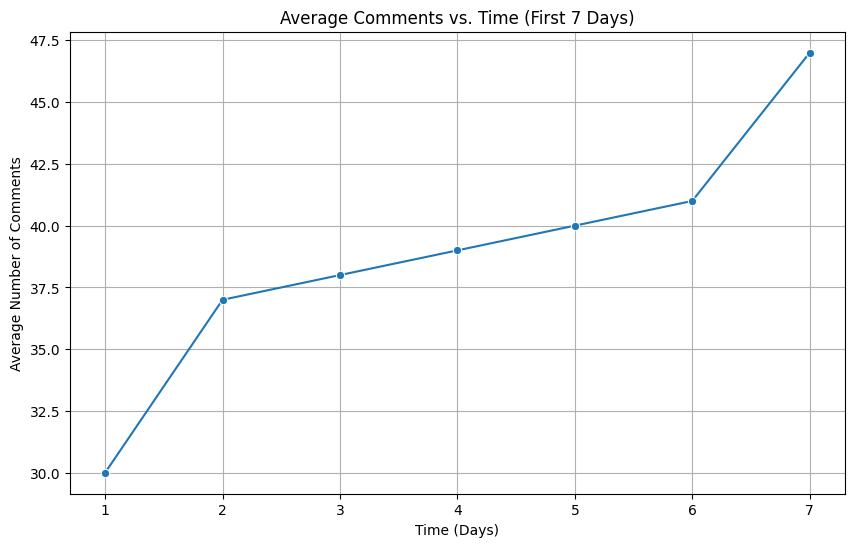

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'time' and calculate the average comments
avg_comments_per_time = df1.groupby('time')['comments'].mean().reset_index()

# Filter for the first 7 days (assuming 'time' represents days)
avg_comments_7_days = avg_comments_per_time[avg_comments_per_time['time'] <= 7]

plt.figure(figsize=(10, 6))
sns.lineplot(x='time', y='comments', data=avg_comments_7_days, marker='o')
plt.title('Average Comments vs. Time (First 7 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Average Number of Comments')
plt.grid(True)
plt.xticks(avg_comments_7_days['time'])
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model re-fitted successfully for plotting 'sf' and 'sf2'.


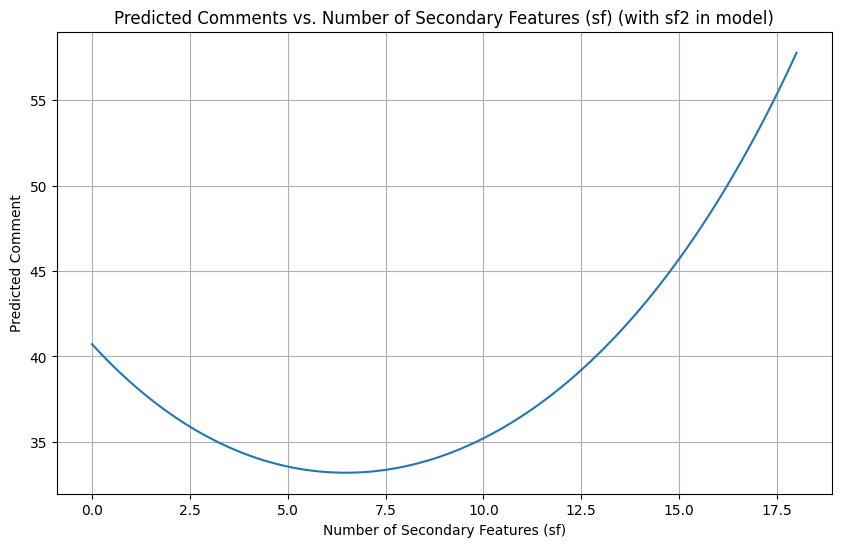

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# The X_var from the model including sf and sf2
X_var_with_sf2 = ['time', 'logwc','pf','saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']

# Re-create data_for_share_model and scaler that includes 'sf' and 'sf2'
Y_cmt = df1['comments']
X_cmt_with_sf2 = df1[X_var_with_sf2]

data_for_cmt_model_with_sf2 = pd.concat([Y_cmt, X_cmt_with_sf2], axis=1)
data_for_cmt_model_with_sf2 = data_for_cmt_model_with_sf2.dropna(subset=['comments'] + X_var_with_sf2)
data_for_cmt_model_with_sf2['comments'] = data_for_cmt_model_with_sf2['comments'].astype(float).astype(int)

Y_clear_with_sf2 = data_for_cmt_model_with_sf2['comments']
X_clear_with_sf2 = data_for_cmt_model_with_sf2[X_var_with_sf2]

# Re-initialize and fit scaler for the model with sf and sf2
scaler_with_sf2 = StandardScaler()
X_scaled_with_sf2 = scaler_with_sf2.fit_transform(X_clear_with_sf2)
X_clear_with_sf2 = pd.DataFrame(X_scaled_with_sf2, columns=X_var_with_sf2, index=X_clear_with_sf2.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear_with_sf2 = sm.add_constant(X_clear_with_sf2, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_cmt_with_sf2 = X_clear_with_sf2
try:
    zinb_cmodel_with_sf2 = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear_with_sf2, exog=X_clear_with_sf2, exog_infl=infl_cmt_with_sf2) # Corrected variable name here
    try:
        start_params_with_sf2 = zinb_cmodel_with_sf2.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_with_sf2 = np.zeros(len(X_clear_with_sf2.columns) * 2 + 1)
    zinb_cmt_results_with_sf2 = zinb_cmodel_with_sf2.fit(maxiter=1000, disp=False, start_params=start_params_with_sf2)
    print("Model re-fitted successfully for plotting 'sf' and 'sf2'.")
except Exception as e:
    print(f"An error occurred during re-fitting model for 'sf' and 'sf2' plotting: {e}")

# Get the original (unscaled) X_var for reference
original_X_with_sf2 = data_for_cmt_model_with_sf2[X_var_with_sf2]

# Create a DataFrame for prediction
# We want to vary 'sf' and keep other variables at their mean, and calculate 'sf2'
sf_range_for_plot = np.linspace(original_X_with_sf2['sf'].min(), original_X_with_sf2['sf'].max(), 100)

# Create a dictionary to hold the mean values for other predictors
mean_values_with_sf2 = original_X_with_sf2.mean().to_dict()

# Create a list of prediction dataframes
prediction_dfs_with_sf2 = []
for val_sf in sf_range_for_plot:
    pred_data = mean_values_with_sf2.copy()
    pred_data['sf'] = val_sf # Set 'sf' to the current value
    pred_data['sf2'] = val_sf ** 2 # Calculate 'sf2' from 'sf'
    prediction_dfs_with_sf2.append(pd.DataFrame([pred_data]))

# Concatenate all prediction dataframes
X_pred_unscaled_with_sf2 = pd.concat(prediction_dfs_with_sf2, ignore_index=True)

# Ensure the order of columns in X_pred_unscaled_with_sf2 matches X_var_with_sf2 for scaling
X_pred_unscaled_with_sf2 = X_pred_unscaled_with_sf2[X_var_with_sf2]

# Scale the prediction data using the *same scaler* fitted to the original data including sf2
X_pred_scaled_with_sf2 = scaler_with_sf2.transform(X_pred_unscaled_with_sf2)
X_pred_scaled_with_sf2 = pd.DataFrame(X_pred_scaled_with_sf2, columns=X_var_with_sf2, index=X_pred_unscaled_with_sf2.index)

# Add constant to the scaled prediction data
X_pred_scaled_with_sf2 = sm.add_constant(X_pred_scaled_with_sf2, prepend=False)

# Make predictions using the model that includes sf and sf2
predicted_cmt_with_sf2 = zinb_cmt_results_with_sf2.predict(exog=X_pred_scaled_with_sf2, exog_infl=X_pred_scaled_with_sf2)

# Create a DataFrame for plotting
plot_df_with_sf2 = pd.DataFrame({'sf': sf_range_for_plot, 'Predicted Cmt': predicted_cmt_with_sf2})

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='sf', y='Predicted Cmt', data=plot_df_with_sf2)
plt.title('Predicted Comments vs. Number of Secondary Features (sf) (with sf2 in model)')
plt.xlabel('Number of Secondary Features (sf)')
plt.ylabel('Predicted Comment')
plt.grid(True)
plt.show()

In [25]:
# Define the formula for the quantile regression model
# Using the same predictors as the ZINB model for consistency
formula = 'comments ~ pf + sf + sf2 + time + logwc + saturation + post_interval + revenue + Q("page active")'

# List of quantiles to analyze
quantiles = [0.50, 0.70, 0.90]

print("Performing Quantile Regression for different quantiles...")

# Loop through each quantile and fit the model
for q in quantiles:
    print(f"\n--- Quantile Regression for {int(q*100)}th Percentile ---")
    # Fit the Quantile Regression model
    mod = smf.quantreg(formula, data=df1)
    res = mod.fit(q=q)

    # Print the summary of the results
    print(res.summary())

print("Quantile Regression analysis complete.")

Performing Quantile Regression for different quantiles...

--- Quantile Regression for 50th Percentile ---
                         QuantReg Regression Results                          
Dep. Variable:               comments   Pseudo R-squared:              0.03869
Model:                       QuantReg   Bandwidth:                       10.42
Method:                 Least Squares   Sparsity:                        82.38
Date:                Tue, 18 Aug 2026   No. Observations:                 2191
Time:                        03:13:41   Df Residuals:                     2181
                                        Df Model:                            9
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -16.4600      6.522     -2.524      0.012     -29.249      -3.671
pf                  -0.1152      0.524     -0.220      0.826      -1.143       0.913


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


                         QuantReg Regression Results                          
Dep. Variable:               comments   Pseudo R-squared:             0.009292
Model:                       QuantReg   Bandwidth:                       10.15
Method:                 Least Squares   Sparsity:                        53.04
Date:                Tue, 18 Aug 2026   No. Observations:                 2191
Time:                        03:13:42   Df Residuals:                     2181
                                        Df Model:                            9
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           31.8272      3.877      8.210      0.000      24.225      39.430
pf                  -0.1378      0.325     -0.424      0.672      -0.776       0.500
sf                  -1.8055      0.448     -4.035      0.000      -2.683      -0.928
sf2                  0

## Mixed-Effects Model

A mixed-effects model is a statistical model that contains both fixed effects and random effects. Fixed effects are parameters that are constant across individuals or groups, while random effects are associated with individual observations drawn from a population, typically used to account for within-group correlations. They are particularly useful when you have data structured in groups or clusters, and you expect observations within the same group to be more similar to each other than to observations from different groups. In this case, `page active` is treated as a random effect, allowing the intercept (and potentially other coefficients) to vary across different 'page active' groups.

In [26]:
# Define the formula for the mixed-effects model
# 'comments' is the dependent variable
# 'pf + sf + sf2 + time + logwc + saturation + post_interval + revenue' are fixed effects
# 'page active' is specified as the grouping variable for random effects
formula = 'comments ~ pf + sf + sf2 + time + logwc + saturation + post_interval + revenue'

# Identify all columns used in the model, including the dependent variable and groups
model_columns = ['comments', 'pf', 'sf', 'sf2', 'time', 'logwc', 'saturation', 'post_interval', 'revenue', 'page active']

# Create a new DataFrame with only the relevant columns and drop rows with NaN values
# This ensures that 'data' and 'groups' have perfectly aligned indices and sizes
model_df = df1[model_columns].dropna()

# Fit the Mixed-Effects Model
# Pass the cleaned model_df and its 'page active' column for groups
print("Fitting Mixed-Effects Model for 'comments'...")
mixed_model = MixedLM.from_formula(formula, data=model_df, groups=model_df["page active"])

# Try to fit the model. It might take a moment.
# Using a robust covariance estimator can help with issues like heteroscedasticity
try:
    mixed_results = mixed_model.fit(maxiter=1000)
    print(mixed_results.summary())
except Exception as e:
    print(f"An error occurred during mixed-effects model fitting: {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Ensure the grouping variable has sufficient variation (more than one group).")
    print("3. Consider simplifying the random effects structure if convergence is an issue.")
    print("4. Try different optimization algorithms or increasing maxiter.")

Fitting Mixed-Effects Model for 'comments'...
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: comments   
No. Observations: 2191    Method:             REML       
No. Groups:       15      Scale:              3855.3198  
Min. group size:  67      Log-Likelihood:     -12167.2319
Max. group size:  283     Converged:          Yes        
Mean group size:  146.1                                  
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      36.041   12.355  2.917 0.004 11.825 60.256
pf             -1.532    0.793 -1.931 0.053 -3.086  0.023
sf             -1.695    1.103 -1.537 0.124 -3.857  0.467
sf2             0.125    0.105  1.193 0.233 -0.080  0.331
time           -0.001    0.005 -0.167 0.867 -0.011  0.009
logwc           0.390    3.051  0.128 0.898 -5.590  6.370
saturation      0.055    0.030  1.80

## Generalized Negative Binomial Model

A Generalized Negative Binomial (GNB) regression model is a type of count data model used when the dependent variable represents counts (non-negative integers) and exhibits overdispersion, meaning its variance is greater than its mean. It is an extension of the Poisson regression model, which assumes equidispersion (variance equals mean). The GNB model introduces an additional parameter (often denoted as $\alpha$ or $k$) to account for this excess variability, allowing for more flexible modeling of the data. It's particularly useful when dealing with phenomena like comment counts, where rare events (many zeros) and higher variability are common.

In [27]:
# Define dependent and independent variables for the GNB model
Y_comments_gnb = df1['comments']
X_var_gnb = ['time', 'logwc','pf', 'saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']
X_comments_gnb = df1[X_var_gnb]

# Combine and drop NaNs to ensure consistent data for the model
data_for_gnb_model = pd.concat([Y_comments_gnb, X_comments_gnb], axis=1)
data_for_gnb_model = data_for_gnb_model.dropna(subset=['comments'] + X_var_gnb)
data_for_gnb_model['comments'] = data_for_gnb_model['comments'].astype(float).astype(int)

Y_clear_gnb = data_for_gnb_model['comments']
X_clear_gnb = data_for_gnb_model[X_var_gnb]

# Scale the independent variables
scaler_gnb = StandardScaler()
X_scaled_gnb = scaler_gnb.fit_transform(X_clear_gnb)
X_clear_gnb = pd.DataFrame(X_scaled_gnb, columns=X_var_gnb, index=X_clear_gnb.index)

# Add a constant (intercept) to the independent variables
X_clear_gnb = sm.add_constant(X_clear_gnb, prepend=False)

try:
    print("Fitting Generalized Negative Binomial Regression model for 'comments'...")
    gnb_model = NegativeBinomial(endog=Y_clear_gnb, exog=X_clear_gnb)

    # Attempt to get default start_params if available or initialize with zeros
    try:
        # Try a quick fit for initial params, then perturb to avoid local optima
        start_params_gnb = gnb_model.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params_gnb = np.zeros(len(X_clear_gnb.columns) + 1) # exog_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    gnb_results = gnb_model.fit(maxiter=1000, disp=False, start_params=start_params_gnb)
    print(gnb_results.summary())
except Exception as e:
    print(f"An error occurred during GNB model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables if not already done.")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers).")

Fitting Generalized Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                 2191
Model:               NegativeBinomial   Df Residuals:                     2181
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.001572
Time:                        03:13:43   Log-Likelihood:                -9693.8
converged:                       True   LL-Null:                       -9709.1
Covariance Type:            nonrobust   LLR p-value:                 0.0003569
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.0178      0.037      0.483      0.629      -0.054       0.090
logwc             0.0654      0.032      2.029      0.042       0.002       0.129
pf               -0.0765      0.030     

### Hurdle Model for Facebook Comments

A hurdle model is a two-part model for count data with an excess of zeros. It consists of:

1.  **A binary model (e.g., Logistic Regression):** This models the probability of crossing the "hurdle" (i.e., having a non-zero count of shares).
2.  **A zero-truncated count model (e.g., Truncated Negative Binomial):** This models the count given that the hurdle has been crossed (i.e., only for posts with at least one share). Since `statsmodels` does not directly provide a zero-truncated negative binomial, we will use a standard Negative Binomial model on the subset of data where `Comments > 0`.

We will use the same comprehensive set of predictors `['pf', 'sf', 'sf2', 'time', 'logwc', 'saturation', 'post_interval', 'revenue', 'page active']` that was used in the ZINB model.

In [28]:
# Define dependent and independent variables for the hurdle model
Y = df1['comments']
X_var = ['time', 'logwc','pf','saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']
X = df1[X_var]

# Combine and drop NaNs to ensure consistent data
data_for_hurdle_model = pd.concat([Y, X], axis=1)
data_for_hurdle_model = data_for_hurdle_model.dropna(subset=['comments'] + X_var)

# Convert comments to integer for count models
data_for_hurdle_model['comments'] = data_for_hurdle_model['comments'].astype(float).astype(int)

# --- Part 1: Hurdle Model (Binary: comments > 0) ---
print("\n--- Hurdle Model Part 1: Logistic Regression for comments > 0 ---\n")

# Create a binary dependent variable: 1 if comments > 0, 0 otherwise
data_for_hurdle_model['has_comments'] = (data_for_hurdle_model['comments'] > 0).astype(int)

Y_binary = data_for_hurdle_model['has_comments']
X_binary = data_for_hurdle_model[X_var]

# Scale the independent variables for the binary part
scaler_binary = StandardScaler()
X_scaled_binary = scaler_binary.fit_transform(X_binary)
X_scaled_binary = pd.DataFrame(X_scaled_binary, columns=X_var, index=X_binary.index)

# Add a constant (intercept)
X_scaled_binary = sm.add_constant(X_scaled_binary, prepend=False)

try:
    logit_model = sm.Logit(Y_binary, X_scaled_binary)
    logit_results = logit_model.fit(disp=False, maxiter=1000)
    print(logit_results.summary())
except Exception as e:
    print(f"An error occurred during Logistic Regression: {e}")


--- Hurdle Model Part 1: Logistic Regression for comments > 0 ---

                           Logit Regression Results                           
Dep. Variable:           has_comments   No. Observations:                 2191
Model:                          Logit   Df Residuals:                     2181
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 0.02720
Time:                        03:13:43   Log-Likelihood:                -1073.0
converged:                       True   LL-Null:                       -1103.0
Covariance Type:            nonrobust   LLR p-value:                 1.341e-09
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.1379      0.067      2.059      0.040       0.007       0.269
logwc             0.3182      0.051      6.293      0.

In [29]:
# --- Part 2: Count Model (Negative Binomial for comments > 0) ---
print("\n--- Hurdle Model Part 2: Negative Binomial Regression for comments (when Shares > 0) ---\n")

# Filter data to include only posts with shares > 0
df_positive_comments = data_for_hurdle_model[data_for_hurdle_model['comments'] > 0].copy()

Y_count = df_positive_comments['comments']
X_count = df_positive_comments[X_var]

# Scale the independent variables for the count part using a *new* scaler or the previous one fitted on the full dataset (depending on preference)
# For consistency, we will fit a new scaler on the positive shares data
scaler_count = StandardScaler()
X_scaled_count = scaler_count.fit_transform(X_count)
X_scaled_count = pd.DataFrame(X_scaled_count, columns=X_var, index=X_count.index)

# Add a constant (intercept)
X_scaled_count = sm.add_constant(X_scaled_count, prepend=False)

try:
    nb_model = sm.NegativeBinomial(Y_count, X_scaled_count)
    # Try to get initial parameters, and if not available, create a default
    try:
        start_params_nb = nb_model.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        start_params_nb = np.zeros(len(X_scaled_count.columns) + 1) # exog_params + alpha

    nb_results = nb_model.fit(disp=False, maxiter=1000, start_params=start_params_nb)
    print(nb_results.summary())
except Exception as e:
    print(f"An error occurred during Negative Binomial Regression: {e}")


--- Hurdle Model Part 2: Negative Binomial Regression for comments (when Shares > 0) ---

                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                 1748
Model:               NegativeBinomial   Df Residuals:                     1738
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.002262
Time:                        03:13:44   Log-Likelihood:                -8388.4
converged:                       True   LL-Null:                       -8407.4
Covariance Type:            nonrobust   LLR p-value:                 1.717e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time             -0.0061      0.025     -0.249      0.804      -0.054       0.042
logwc            -0.0104      0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
#Robustness Check for Negative Binomial Model
original_nbreg_model = sm.NegativeBinomial(Y_count, X_scaled_count)
original_nbreg_result = original_nbreg_model.fit(disp=False)

print("\n--- Original Negative Binomial Regression Results ---")
print(original_nbreg_result.summary())

# --- Robustness Check ---
# Randomly sample 90% of the data for the robustness check
sampled_df_positive_comments = df_positive_comments.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_comments['comments']
X_positive_sampled = X_scaled_count.loc[sampled_df_positive_comments.index] # Ensure X aligns with sampled y

# Fit the Negative Binomial Regression model on the sampled data
nbreg_model_sampled = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled)
nbreg_result_sampled = nbreg_model_sampled.fit(disp=False, maxiter=1000)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results ---")
print(nbreg_result_sampled.summary())

# Create DataFrames for comparison
original_coef_pval = pd.DataFrame({
    'Original_Coef': original_nbreg_result.params,
    'Original_P_Value': original_nbreg_result.pvalues
})

sampled_coef_pval = pd.DataFrame({
    'Sampled_Coef': nbreg_result_sampled.params,
    'Sampled_P_Value': nbreg_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_df = pd.merge(
    original_coef_pval, sampled_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) ---")
display(comparison_df.round(4))


--- Original Negative Binomial Regression Results ---
                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                 1748
Model:               NegativeBinomial   Df Residuals:                     1738
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.002262
Time:                        03:13:44   Log-Likelihood:                -8388.4
converged:                       True   LL-Null:                       -8407.4
Covariance Type:            nonrobust   LLR p-value:                 1.717e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time             -0.0061      0.025     -0.248      0.804      -0.054       0.042
logwc            -0.0104      0.023     -0.459      0.647      -0.0

,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
alpha,0.8064,0.0000,0.7958,0.0000
const,3.8002,0.0000,3.8010,0.0000
logwc,-0.0104,0.6465,-0.0088,0.7062
page active,-0.0041,0.8529,-0.0097,0.6711
pf,-0.0694,0.0008,-0.0876,0.0000
post_interval,0.0639,0.0232,0.0733,0.0223
revenue,0.0551,0.0135,0.0498,0.0313
saturation,0.0451,0.0384,0.0460,0.0434
sf,-0.1453,0.0074,-0.1187,0.0340
sf2,0.1103,0.0327,0.1024,0.0549


In [31]:
#Robustness Check (90% Sampled Data) Logistic Regression Results
original_logit_model = sm.Logit(Y_binary, X_scaled_binary)
original_logit_result = original_logit_model.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Original Logistic Regression Results ---")
print(original_logit_result.summary())

# --- Robustness Check for Logistic Regression ---
# Randomly sample 90% of the data for the robustness check
sampled_df_logit = data_for_hurdle_model.sample(frac=0.9, random_state=42)

y_binary_sampled = sampled_df_logit['has_comments']
X_sampled = X_scaled_binary.loc[sampled_df_logit.index] # Ensure X aligns with sampled y_binary

# Fit the Logistic Regression model on the sampled data
logit_model_sampled = sm.Logit(y_binary_sampled, X_sampled)
logit_result_sampled = logit_model_sampled.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Robustness Check (90% Sampled Data) Logistic Regression Results ---")
print(logit_result_sampled.summary())

# Create DataFrames for comparison
original_logit_coef_pval = pd.DataFrame({
    'Original_Coef': original_logit_result.params,
    'Original_P_Value': original_logit_result.pvalues
})

sampled_logit_coef_pval = pd.DataFrame({
    'Sampled_Coef': logit_result_sampled.params,
    'Sampled_P_Value': logit_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_logit_df = pd.merge(
    original_logit_coef_pval, sampled_logit_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Logistic Regression ---")
display(comparison_logit_df.round(4))


--- Original Logistic Regression Results ---
                           Logit Regression Results                           
Dep. Variable:           has_comments   No. Observations:                 2191
Model:                          Logit   Df Residuals:                     2181
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 0.02720
Time:                        03:13:45   Log-Likelihood:                -1073.0
converged:                       True   LL-Null:                       -1103.0
Covariance Type:            nonrobust   LLR p-value:                 1.341e-09
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.1375      0.067      2.053      0.040       0.006       0.269
logwc             0.3178      0.051      6.286      0.000       0.219       

,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
const,1.4203,0.0000,1.4204,0.0000
logwc,0.3178,0.0000,0.3107,0.0000
page active,0.1769,0.0025,0.1713,0.0051
pf,-0.0161,0.7697,-0.0120,0.8360
post_interval,0.0822,0.2491,0.0908,0.2576
revenue,-0.0951,0.0756,-0.1160,0.0386
saturation,0.1664,0.0041,0.1851,0.0025
sf,-0.2597,0.0896,-0.2272,0.1580
sf2,0.2588,0.1083,0.2623,0.1259
time,0.1375,0.0400,0.1694,0.0220


In [32]:
#Robustness Check for Negative Binomial Model with Clustered Robust Standard Errors
# --- Ensure X and y are set up for the full model
features = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2']

y = df1['comments']
X = df1[features]

X = sm.add_constant(X)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.fillna(X.mean())

constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

df_positive_likes = df1[df1['comments'] > 0]
y_positive = df_positive_likes['comments']
X_positive = X.loc[df_positive_likes.index]

# --- Original Negative Binomial Model with Clustered Robust Standard Errors ---
original_nbreg_model_cluster = sm.NegativeBinomial(y_positive, X_positive)
original_nbreg_result_cluster = original_nbreg_model_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': df_positive_likes['page active']}
)

print("\n--- Original Negative Binomial Regression Results (Clustered Robust SE) ---")
print(original_nbreg_result_cluster.summary())

# --- Robustness Check (90% Sampled Data) with Clustered Robust Standard Errors ---
sampled_df_positive_likes = df_positive_likes.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_likes['comments'] # Corrected: should be 'shares', not 'likes'
X_positive_sampled = X_positive.loc[sampled_df_positive_likes.index] # Ensure X aligns with sampled y

# Fit the Negative Binomial Regression model on the sampled data with clustered robust SE
nbreg_model_sampled_cluster = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled)
nbreg_result_sampled_cluster = nbreg_model_sampled_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': sampled_df_positive_likes['page active']}
)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results (Clustered Robust SE) ---")
print(nbreg_result_sampled_cluster.summary())

# --- Create DataFrames for comparison ---
original_cluster_coef_pval = pd.DataFrame({
    'Original_Cluster_Coef': original_nbreg_result_cluster.params,
    'Original_Cluster_P_Value': original_nbreg_result_cluster.pvalues
})

sampled_cluster_coef_pval = pd.DataFrame({
    'Sampled_Cluster_Coef': nbreg_result_sampled_cluster.params,
    'Sampled_Cluster_P_Value': nbreg_result_sampled_cluster.pvalues
})

# Merge for side-by-side comparison
comparison_cluster_df = pd.merge(
    original_cluster_coef_pval, sampled_cluster_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled with Clustered Robust SE) ---")
display(comparison_cluster_df.round(4))

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Original Negative Binomial Regression Results (Clustered Robust SE) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                 1748
Model:               NegativeBinomial   Df Residuals:                     1738
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 -0.2146
Time:                        03:13:46   Log-Likelihood:                -10212.
converged:                      False   LL-Null:                       -8407.4
Covariance Type:              cluster   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8223      0.454      8.425      0.000       2.933       4.712
time           1.226e-05      0.000      0.08

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results (Clustered Robust SE) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                 1573
Model:               NegativeBinomial   Df Residuals:                     1563
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 -0.2039
Time:                        03:13:46   Log-Likelihood:                -9109.0
converged:                      False   LL-Null:                       -7566.0
Covariance Type:              cluster   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8436      0.409      9.390      0.000       3.041       4.646
time           3.2

,Original_Cluster_Coef,Original_Cluster_P_Value,Sampled_Cluster_Coef,Sampled_Cluster_P_Value
alpha,8.5230,0.0063,7.8818,0.0073
const,3.8223,0.0000,3.8436,0.0000
logwc,-0.0170,0.7477,-0.0169,0.7177
page active,0.0000,0.9818,-0.0000,0.8730
pf,-0.0461,0.0175,-0.0585,0.0035
post_interval,0.0086,0.3217,0.0094,0.4190
revenue,0.0258,0.2156,0.0250,0.2646
saturation,0.0010,0.0445,0.0010,0.0096
sf,-0.0412,0.1910,-0.0319,0.2648
sf2,0.0029,0.2342,0.0025,0.2804


In [ ]:
# Robustness Check for Zero-Inflated Negative Binomial Model

# --- Original Zero-Inflated Negative Binomial Regression Model ---
# Using the variables from the most comprehensive ZINB model setup (cell _3d3yqNiC5BA)
Y_clear_zinb = data_for_cmt_model_with_sf2['comments']
X_clear_zinb = X_clear_with_sf2 # This is the scaled X with constant from _3d3yqNiC5BA

try:
    original_zinb_model = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear_zinb, exog=X_clear_zinb, exog_infl=X_clear_zinb)
    # Attempt to get default start_params or initialize with zeros
    try:
        start_params_original_zinb = original_zinb_model.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_original_zinb = np.zeros(len(X_clear_zinb.columns) * 2 + 1)
    original_zinb_result = original_zinb_model.fit(maxiter=1000, disp=False, start_params=start_params_original_zinb)
    print("\n--- Original Zero-Inflated Negative Binomial Regression Results ---")
    print(original_zinb_result.summary())
except Exception as e:
    print(f"An error occurred during original ZINB model fitting: {e}")

# --- Robustness Check for Zero-Inflated Negative Binomial Regression ---
# Randomly sample 90% of the data for the robustness check
# Use data_for_share_model_with_sf2 which was used for the main ZINB model
sampled_df_zinb_check = data_for_cmt_model_with_sf2.sample(frac=0.9, random_state=42)

y_zinb_sampled = sampled_df_zinb_check['comments']

# Prepare exogenous variables for the sampled data
# Use the same scaler (scaler_with_sf2 from ecee7edb) that was used for the original ZINB model
# The columns should be the same as X_var_with_sf2 from ecee7edb (and _3d3yqNiC5BA)
X_var_for_zinb = ['time', 'logwc','pf', 'saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']
X_zinb_sampled_unscaled = sampled_df_zinb_check[X_var_for_zinb]

# Re-fit scaler_with_sf2 on the full original data if it's not guaranteed to be in scope from ecee7edb
# This ensures consistency even if cells were run out of order
scaler_with_sf2_re_fit = StandardScaler()
scaler_with_sf2_re_fit.fit(data_for_cmt_model_with_sf2[X_var_for_zinb])

X_zinb_sampled_scaled = scaler_with_sf2_re_fit.transform(X_zinb_sampled_unscaled)
X_zinb_sampled = pd.DataFrame(X_zinb_sampled_scaled, columns=X_var_for_zinb, index=X_zinb_sampled_unscaled.index)

# Add a constant (intercept) to the independent variables
X_zinb_sampled = sm.add_constant(X_zinb_sampled, prepend=False)

# Fit the Zero-Inflated Negative Binomial Regression model on the sampled data
try:
    zinb_model_sampled = sm.ZeroInflatedNegativeBinomialP(endog=y_zinb_sampled, exog=X_zinb_sampled, exog_infl=X_zinb_sampled)
    # Attempt to get initial parameters or initialize with zeros
    try:
        start_params_sampled_zinb = zinb_model_sampled.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_sampled_zinb = np.zeros(len(X_zinb_sampled.columns) * 2 + 1)
    zinb_result_sampled = zinb_model_sampled.fit(maxiter=1000, disp=False, start_params=start_params_sampled_zinb)
    print("\n--- Robustness Check (90% Sampled Data) Zero-Inflated Negative Binomial Regression Results ---")
    print(zinb_result_sampled.summary())
except Exception as e:
    print(f"An error occurred during sampled ZINB model fitting: {e}")


# Create DataFrames for comparison
original_zinb_coef_pval = pd.DataFrame({
    'Original_Coef': original_zinb_result.params,
    'Original_P_Value': original_zinb_result.pvalues
})

sampled_zinb_coef_pval = pd.DataFrame({
    'Sampled_Coef': zinb_result_sampled.params,
    'Sampled_P_Value': zinb_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_zinb_df = pd.merge(
    original_zinb_coef_pval, sampled_zinb_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Zero-Inflated Negative Binomial Regression ---")
display(comparison_zinb_df.round(4))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Original Zero-Inflated Negative Binomial Regression Results ---
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2181
Method:                                      MLE   Df Model:                            9
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.005080
Time:                                   03:13:59   Log-Likelihood:                -9438.0
converged:                                  True   LL-Null:                       -9486.2
Covariance Type:                       nonrobust   LLR p-value:                 8.490e-17
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time             -0.162

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Poisson Hurdle Regression Model

This section implements a two-part Poisson Hurdle model to account for the excess zeros in the 'comments' variable.

1.  **Part 1: Binary Logistic Regression**
    Predicts the probability that `comments > 0` (i.e., a post receives at least one comment) versus `comment = 0`.

2.  **Part 2: Zero-Truncated Poisson Regression**
    Predicts the number of `comments` given that `comments > 0`. This model only considers observations where `comments` are positive.

The final prediction from the Hurdle model is the product of the probability from Part 1 and the expected value from Part 2.

In [ ]:
# Define features for the Hurdle model (using the same as the last comprehensive model)
features = ['time', 'logwc','pf', 'saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']

# Prepare dependent and independent variables for the entire dataset
y_full = df1['comments']
X_full = df1[features]

# Ensure sf2 is calculated consistently
X_full['sf2'] = X_full['sf'] ** 2

# Add constant for statsmodels
X_full = sm.add_constant(X_full)

# Ensure all columns in X_full are numeric and handle NaNs
for col in X_full.columns:
    X_full[col] = pd.to_numeric(X_full[col], errors='coerce')
X_full = X_full.fillna(X_full.mean())

# Drop constant columns if any, excluding the 'const' column
constant_cols_full = [col for col in X_full.columns if col != 'const' and X_full[col].nunique() <= 1]
if constant_cols_full:
    print(f"Dropping constant or near-constant columns in full X: {constant_cols_full}")
    X_full = X_full.drop(columns=constant_cols_full)

# --- Part 1: Logistic Regression for Zero vs. Non-Zero comments ---
print("\n--- Fitting Logistic Regression for Zero vs. Non-Zero comments ---")
df1['has_comments'] = (df1['comments'] > 0).astype(int)
y_binary_full = df1['has_comments']

logit_model_hurdle = sm.Logit(y_binary_full, X_full)
logit_result_hurdle = logit_model_hurdle.fit_regularized(method='l1', alpha=0.1, disp=False)
print(logit_result_hurdle.summary())

# --- Part 2: Zero-Truncated Poisson Regression for Positive comments Only ---
print("\n--- Fitting Zero-Truncated Poisson Regression for Positive comments Only ---")

# Filter data for positive 'comments' only (using the pre-existing df_positive_comments and X_positive)
df_positive_comments = df1[df1['comments'] > 0]
y_positive = df_positive_comments['comments']
X_positive = X_full.loc[df_positive_comments.index] # Use the prepared X_full and align with positive comments

# Zero-Truncated Poisson model
# To address AttributeError: module 'statsmodels.api' has no attribute 'discrete'
# we need to import statsmodels.discrete.discrete_model directly to access ZeroTruncatedPoisson.
import statsmodels.discrete.discrete_model as smdm

# Check if ZeroTruncatedPoisson is available in statsmodels.discrete.discrete_model
if hasattr(smdm, 'ZeroTruncatedPoisson'):
    ztp_model = smdm.ZeroTruncatedPoisson(y_positive, X_positive)
else:
    print("Warning: ZeroTruncatedPoisson not directly found in statsmodels.discrete.discrete_model.")
    print("Falling back to a standard Poisson model for positive values. Interpretation should be cautious.")
    ztp_model = sm.Poisson(y_positive, X_positive)

ztp_result_hurdle = ztp_model.fit(disp=False, maxiter=1000) # Increased maxiter for convergence
print(ztp_result_hurdle.summary())


### Heckman Two-Step Model for Facebook Shares

This section implements the Heckman two-step selection model to account for potential selection bias. The model consists of two main stages:

1.  **Selection Equation (Probit Model):** This models the probability that a post receives at least one share (`shares > 0`).
2.  **Outcome Equation (OLS Regression):** This models the number of shares for posts that received at least one share (`shares > 0`), incorporating a correction term (Inverse Mills Ratio) derived from the selection equation.

In [ ]:
# --- Heckman Step 1: Probit Model for Selection Equation ---
print("\n--- Heckman Step 1: Probit Model for Selection (has_comments > 0) ---")

# Dependent variable: has_comments (from previous hurdle model preparation)
y_selection = df1['has_comments']

# Independent variables (X_full was prepared for the hurdle model and includes 'sf2' and 'const')
X_selection = X_full

# Fit the Probit model
probit_model = sm.Probit(y_selection, X_selection)
probit_results = probit_model.fit(disp=False, maxiter=1000)
print(probit_results.summary())

# Calculate predicted probabilities from the Probit model
predicted_probs = probit_results.predict(X_selection)

# Calculate the Inverse Mills Ratio (IMR)
# IMR = pdf(probit_score) / cdf(probit_score)
# probit_score = X_selection @ probit_results.params

# Make sure to handle cases where cdf is very close to 0 or 1 to avoid division by zero or infinity
# Use the probit_results.exposure which already handles cases when probit is near 0 or 1.

# Need to manually calculate IMR since statsmodels probit doesn't directly give IMR for a Heckman context
# Manual calculation from parameters and X values
lin_pred_probit = probit_results.predict(X_selection, linear=True)

# Import norm from scipy.stats for PDF and CDF functions
from scipy.stats import norm as scipy_norm

phi = scipy_norm.pdf(lin_pred_probit) # PDF of standard normal
PHI = scipy_norm.cdf(lin_pred_probit) # CDF of standard normal

# Avoid division by zero for IMR
IMR = np.where(PHI == 0, 0, phi / PHI)

# Add IMR to the original dataframe, aligning by index
df1['IMR'] = IMR

In [ ]:
# --- Heckman Step 2: OLS Regression for Outcome Equation ---
print("\n--- Heckman Step 2: OLS Regression for Outcome (comments > 0) with IMR ---")

# Filter data to include only posts with shares > 0 (where the outcome is observed)
observed_df = df1[df1['comments'] > 0].copy()

# Dependent variable for the outcome equation
y_outcome = observed_df['comments']

# Independent variables for the outcome equation (including the constant)
# Use the same features as X_full, and add the calculated IMR
# Make sure to get the X values corresponding to the observed_df indices
X_outcome = X_full.loc[observed_df.index].copy()
X_outcome['IMR'] = observed_df['IMR']

# Fit the OLS model
ols_model = sm.OLS(y_outcome, X_outcome)
ols_results = ols_model.fit()
print(ols_results.summary())

In [ ]:
#CLUSTER WITH PERSON AND PLANTS

Y_comments = df1['comments']
X_var = ['time','logwc','pf','saturation','post_interval','revenue','sf','sf2','page active','person','plant']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

In [ ]:
#THREE CLUSTER APPROACH

Y_comments = df1['comments']
X_var = ['time','logwc','saturation','post_interval','revenue','page active','pf','sf','sf2','cluster2','cluster3']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

In [ ]:
df1['sfr2'] = df1['sfr'] ** 2
df1['sfr2'].head()

In [ ]:
#REGRESSION MODEL WITH PRIMARY FEATURES

Y_comments = df1['comments']
X_var = ['time','logwc','pfr','saturation','post_interval','revenue','page active']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear

try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

In [ ]:
#REGRESSION MODEL WITH SECONDARY FEATURES

Y_comments = df1['comments']
X_var = ['time','logwc','saturation','post_interval','revenue','page active','sfr']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear

try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

In [ ]:
#REGRESSION MODEL WITH PRIMARY AND SECONDARY FEATURES

Y_comments = df1['comments']
X_var = ['time','logwc','pfr','saturation','post_interval','revenue','page active','sfr','sfr2']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)
data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The X_var from the model including sf and sf2
X_var_with_sf2 = ['time', 'logwc','pfr','saturation', 'post_interval', 'revenue', 'page active', 'sfr', 'sfr2']

# Re-create data_for_share_model and scaler that includes 'sfr' and 'sfr2'
Y_cmt = df1['comments']
X_cmt_with_sf2 = df1[X_var_with_sf2]

data_for_cmt_model_with_sf2 = pd.concat([Y_cmt, X_cmt_with_sf2], axis=1)
data_for_cmt_model_with_sf2 = data_for_cmt_model_with_sf2.dropna(subset=['comments'] + X_var_with_sf2)
data_for_cmt_model_with_sf2['comments'] = data_for_cmt_model_with_sf2['comments'].astype(float).astype(int)

Y_clear_with_sf2 = data_for_cmt_model_with_sf2['comments']
X_clear_with_sf2 = data_for_cmt_model_with_sf2[X_var_with_sf2]

# Re-initialize and fit scaler for the model with sf and sf2
scaler_with_sf2 = StandardScaler()
X_scaled_with_sf2 = scaler_with_sf2.fit_transform(X_clear_with_sf2)
X_clear_with_sf2 = pd.DataFrame(X_scaled_with_sf2, columns=X_var_with_sf2, index=X_clear_with_sf2.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear_with_sf2 = sm.add_constant(X_clear_with_sf2, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_cmt_with_sf2 = X_clear_with_sf2
try:
    zinb_cmodel_with_sf2 = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear_with_sf2, exog=X_clear_with_sf2, exog_infl=infl_cmt_with_sf2) # Corrected variable name here
    try:
        start_params_with_sf2 = zinb_cmodel_with_sf2.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_with_sf2 = np.zeros(len(X_clear_with_sf2.columns) * 2 + 1)
    zinb_cmt_results_with_sf2 = zinb_cmodel_with_sf2.fit(maxiter=1000, disp=False, start_params=start_params_with_sf2)
    print("Model re-fitted successfully for plotting 'sf' and 'sf2'.")
except Exception as e:
    print(f"An error occurred during re-fitting model for 'sf' and 'sf2' plotting: {e}")

# Get the original (unscaled) X_var for reference
original_X_with_sf2 = data_for_cmt_model_with_sf2[X_var_with_sf2]

# Create a DataFrame for prediction
# We want to vary 'sf' and keep other variables at their mean, and calculate 'sf2'
sf_range_for_plot = np.linspace(original_X_with_sf2['sfr'].min(), original_X_with_sf2['sfr'].max(), 100)

# Create a dictionary to hold the mean values for other predictors
mean_values_with_sf2 = original_X_with_sf2.mean().to_dict()

# Create a list of prediction dataframes
prediction_dfs_with_sf2 = []
for val_sf in sf_range_for_plot:
    pred_data = mean_values_with_sf2.copy()
    pred_data['sfr'] = val_sf # Set 'sf' to the current value
    pred_data['sfr2'] = val_sf ** 2 # Calculate 'sf2' from 'sf'
    prediction_dfs_with_sf2.append(pd.DataFrame([pred_data]))

# Concatenate all prediction dataframes
X_pred_unscaled_with_sf2 = pd.concat(prediction_dfs_with_sf2, ignore_index=True)

# Ensure the order of columns in X_pred_unscaled_with_sf2 matches X_var_with_sf2 for scaling
X_pred_unscaled_with_sf2 = X_pred_unscaled_with_sf2[X_var_with_sf2]

# Scale the prediction data using the *same scaler* fitted to the original data including sf2
X_pred_scaled_with_sf2 = scaler_with_sf2.transform(X_pred_unscaled_with_sf2)
X_pred_scaled_with_sf2 = pd.DataFrame(X_pred_scaled_with_sf2, columns=X_var_with_sf2, index=X_pred_unscaled_with_sf2.index)

# Add constant to the scaled prediction data
X_pred_scaled_with_sf2 = sm.add_constant(X_pred_scaled_with_sf2, prepend=False)

# Make predictions using the model that includes sf and sf2
predicted_cmt_with_sf2 = zinb_cmt_results_with_sf2.predict(exog=X_pred_scaled_with_sf2, exog_infl=X_pred_scaled_with_sf2)

# Create a DataFrame for plotting
plot_df_with_sf2 = pd.DataFrame({'sfr': sf_range_for_plot, 'Predicted Cmt': predicted_cmt_with_sf2})

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='sfr', y='Predicted Cmt', data=plot_df_with_sf2)
plt.title('Predicted Comments vs. Number of Secondary Features (sfr) (with sfr2 in model)')
plt.xlabel('Number of Secondary Features (sfr)')
plt.ylabel('Predicted Comment')
plt.grid(True)
plt.show()

In [ ]:
# Calculate engagement intensity (likes + comments)
df1['engagement_intensity'] = df1['shares'] + df1['comments']

# Ensure 'start date' is in datetime format
df1['start date'] = pd.to_datetime(df1['start date'], format='%d-%m-%Y')

# Extract the day of the week (Monday=0, Sunday=6)
df1['day_of_week'] = df1['start date'].dt.dayofweek

# Group by day of the week and calculate the mean of 'engagement_intensity'
avg_engagement_per_day = df1.groupby('day_of_week')['engagement_intensity'].mean().reset_index()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_engagement_per_day['day_name'] = avg_engagement_per_day['day_of_week'].map(lambda x: day_names[x])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='engagement_intensity', data=avg_engagement_per_day, palette='viridis')
plt.title('Average Engagement Intensity (shares + Comments) per Post by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Engagement Intensity')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Plotting Unit Cost 'e' vs. Total Weighted Engagement

This section explores how varying the unit cost `e` (cost of extracting secondary features) impacts the `total_engagement` calculated by the `faas_case_2` optimization function. All other parameters of the function are kept constant at their example values.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a range for the unit cost 'e' to explore
e_values = range(0, 101, 5)  # From 0 to 100, with a step of 5

# Store results
engagement_results = []

# Fixed parameters for faas_case_2 (from the example run in Jym521nfLmDn)
b_coef = -16.5651
beta = 0.0055
zeta = -0.1224
eta = 0.0106
a = 20.0
c_f = 0.0
budget = 10000.0
q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]
u2 = 18
mu_m = 1.0
weights = [10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10]
scale_factor = 5000.0

# Loop through e_values, call faas_case_2, and collect total_engagement
for e_val in e_values:
    result_e = faas_case_2(
        b_coef=b_coef,
        beta=beta,
        zeta=zeta,
        eta=eta,
        a=a,
        e=float(e_val), # Convert to float
        c_f=c_f,
        budget=budget,
        q=q,
        u2=u2,
        mu_m=mu_m,
        weights=weights,
        scale_factor=scale_factor
    )
    engagement_results.append({
        'unit_cost_e': e_val,
        'total_engagement': result_e['total_engagement']
    })

# Create a DataFrame for plotting
plot_df_e = pd.DataFrame(engagement_results)

# Plotting
plt.figure(figsize=(12, 7))
sns.lineplot(x='unit_cost_e', y='total_engagement', data=plot_df_e, marker='o')
plt.title('Total Weighted Engagement vs. Unit Cost of Secondary Features (e)')
plt.xlabel('Unit Cost of Secondary Features (e)')
plt.ylabel('Total Weighted Engagement')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import math

def produce_table_ec40():
    # Empirical regression parameters (Table 2 & Table EC.35)
    # Shares (m=2)
    b2, beta2, zeta2, eta2 = 2.7067, -0.0500, -0.1012, 0.0098
    # Comments (m=3)
    b3, beta3, zeta3, eta3 = 3.3796, 0.0055, -0.1224, 0.0106

    scale_factor = 5000.0
    u2 = 18
    a = 20.0
    budget = 10000.0
    c_f = 0.0

    # Engagement weights
    mu2, mu3 = 0.7, 0.3

    # Days setup (K = 14)
    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]
    weights = [10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10]
    K = len(weights)

    # Precompute g_2j and g_3j lookup tables
    g2 = [(b2 + zeta2 * j + eta2 * (j**2)) * scale_factor for j in range(u2 + 1)]
    g3 = [(b3 + zeta3 * j + eta3 * (j**2)) * scale_factor for j in range(u2 + 1)]

    # Sort days by engagement weights
    indexed_weights = sorted(enumerate(weights), key=lambda x: x[1], reverse=True)

    print(f"{'e':<6}{'Optimal U':<12}{'Weighted Engagement':<22}{'Leftover Budget':<16}")
    print("=" * 56)

    for e in [20, 30, 40, 50, 60, 70, 80, 90]:
        best_engagement = -1.0
        best_U = 0
        best_leftover = 0.0

        # Search over all effort bounds U
        for U in range(u2 + 1):
            cost_primary = a * sum(q)
            b_prime = budget - cost_primary - (e * U) - c_f

            if b_prime < 0:
                continue

            f_k = [0] * K

            # Greedy allocation to max-weighted days
            for day_idx, w in indexed_weights:
                max_r = 0
                for r in range(U, -1, -1):
                    if r * a <= b_prime:
                        max_r = r
                        break
                f_k[day_idx] = max_r
                b_prime -= max_r * a

            # Compute total weighted engagement
            total_eng = 0.0
            for k in range(K):
                x2_k = (beta2 * scale_factor * q[k]) + g2[f_k[k]]
                x3_k = (beta3 * scale_factor * q[k]) + g3[f_k[k]]
                combined_x = (mu2 * x2_k) + (mu3 * x3_k)
                total_eng += weights[k] * combined_x

            if total_eng > best_engagement:
                best_engagement = total_eng
                best_U = U
                best_leftover = b_prime

        print(f"{e:<6}{best_U:<12}{best_engagement:<22.2f}{best_leftover:<16.2f}")

if __name__ == "__main__":
    produce_table_ec40()

In [ ]:
import math

def produce_table_ec42():
    # Empirical regression parameters (Table 2 & Table EC.35)
    # Shares (m=2)
    b2, beta2, zeta2, eta2 = 2.7067, -0.0500, -0.1012, 0.0098
    # Comments (m=3)
    b3, beta3, zeta3, eta3 = 3.3796, 0.0055, -0.1224, 0.0106

    scale_factor = 5000.0
    u2 = 18
    a = 20.0
    budget = 10000.0
    c_f = 0.0

    # Engagement weights
    mu2, mu3 = 0.7, 0.3

    # Primary features (q_k)
    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]

    # REVISED Day weights from Table EC.41 (Thursday & Friday weighted higher)
    weights = [10, 12, 14, 14, 16, 16, 10, 10, 12, 14, 14, 16, 16, 10]
    K = len(weights)

    # Precompute lookup tables
    g2 = [(b2 + zeta2 * j + eta2 * (j**2)) * scale_factor for j in range(u2 + 1)]
    g3 = [(b3 + zeta3 * j + eta3 * (j**2)) * scale_factor for j in range(u2 + 1)]

    # Sort days by engagement weights (descending)
    indexed_weights = sorted(enumerate(weights), key=lambda x: x[1], reverse=True)

    print(f"{'e':<6}{'Optimal U':<12}{'Weighted Engagement':<22}{'Leftover Budget':<16}")
    print("=" * 56)

    for e in [20, 30, 40, 50, 60, 70, 80, 90]:
        best_engagement = -1.0
        best_U = 0
        best_leftover = 0.0

        for U in range(u2 + 1):
            cost_primary = a * sum(q)
            b_prime = budget - cost_primary - (e * U) - c_f

            if b_prime < 0:
                continue

            f_k = [0] * K

            # Greedy allocation to max-weighted days
            for day_idx, w in indexed_weights:
                max_r = 0
                for r in range(U, -1, -1):
                    if r * a <= b_prime:
                        max_r = r
                        break
                f_k[day_idx] = max_r
                b_prime -= max_r * a

            # Compute total weighted engagement
            total_eng = 0.0
            for k in range(K):
                x2_k = (beta2 * scale_factor * q[k]) + g2[f_k[k]]
                x3_k = (beta3 * scale_factor * q[k]) + g3[f_k[k]]
                combined_x = (mu2 * x2_k) + (mu3 * x3_k)
                total_eng += weights[k] * combined_x

            if total_eng > best_engagement:
                best_engagement = total_eng
                best_U = U
                best_leftover = b_prime

        print(f"{e:<6}{best_U:<12}{best_engagement:<22.2f}{best_leftover:<16.2f}")

if __name__ == "__main__":
    produce_table_ec42()